# 🛒 Amazon Product Search Ranking — Sorting Algorithms in E-Commerce

**Session 1 | Industrial Use Case 3 | DSA & ML for Business**

---

### Business Context
- Amazon processes **8.5 billion searches/day** — each returns sorted product results
- Product ranking directly determines **which products sell** — position #1 gets **35% of clicks**
- Amazon's marketplace has **350M+ products** — sorting speed = revenue speed
- A **100ms delay** in page load costs Amazon ~**$1.6B/year** in lost sales

### What You'll Learn
1. Build a **weighted composite ranking score** from multiple product signals
2. Compare **Selection Sort, QuickSort, and Python TimSort** on 1,000 products
3. Analyze how **ranking weight changes** affect which products appear in top-10
4. Estimate **infrastructure cost impact** of algorithm choice at Amazon scale

## Step 1: Import Libraries & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("../datasets/amazon_product_ranking.csv")
print(f"Dataset: {df.shape[0]} products, {df.shape[1]} features")
print(f"\nCategories: {df['category'].nunique()} — {list(df['category'].unique())}")
print(f"Prime products: {df['is_prime'].mean():.0%}")
print(f"\nPrice range: ${df['price'].min():.2f} — ${df['price'].max():.2f}")
df.head()

Dataset: 1000 products, 10 features

Categories: 8 — ['Beauty', 'Home & Kitchen', 'Sports', 'Clothing', 'Grocery', 'Books', 'Toys', 'Electronics']
Prime products: 58%

Price range: $1.62 — $1679.48


,product_id,category,avg_rating,num_reviews,price,relevance_score,seller_rating,delivery_days,is_prime,return_rate
0,ASIN_00001,Beauty,4.07,23477,107.03,0.314,4.64,1,1,0.280
1,ASIN_00002,Home & Kitchen,5.00,49235,47.93,0.145,4.04,14,1,0.063
2,ASIN_00003,Sports,4.56,8085,29.75,0.752,3.91,1,1,0.137
3,ASIN_00004,Beauty,3.34,7104,51.82,0.200,4.37,2,0,0.124
4,ASIN_00005,Clothing,3.08,25436,6.88,0.647,4.67,1,1,0.128


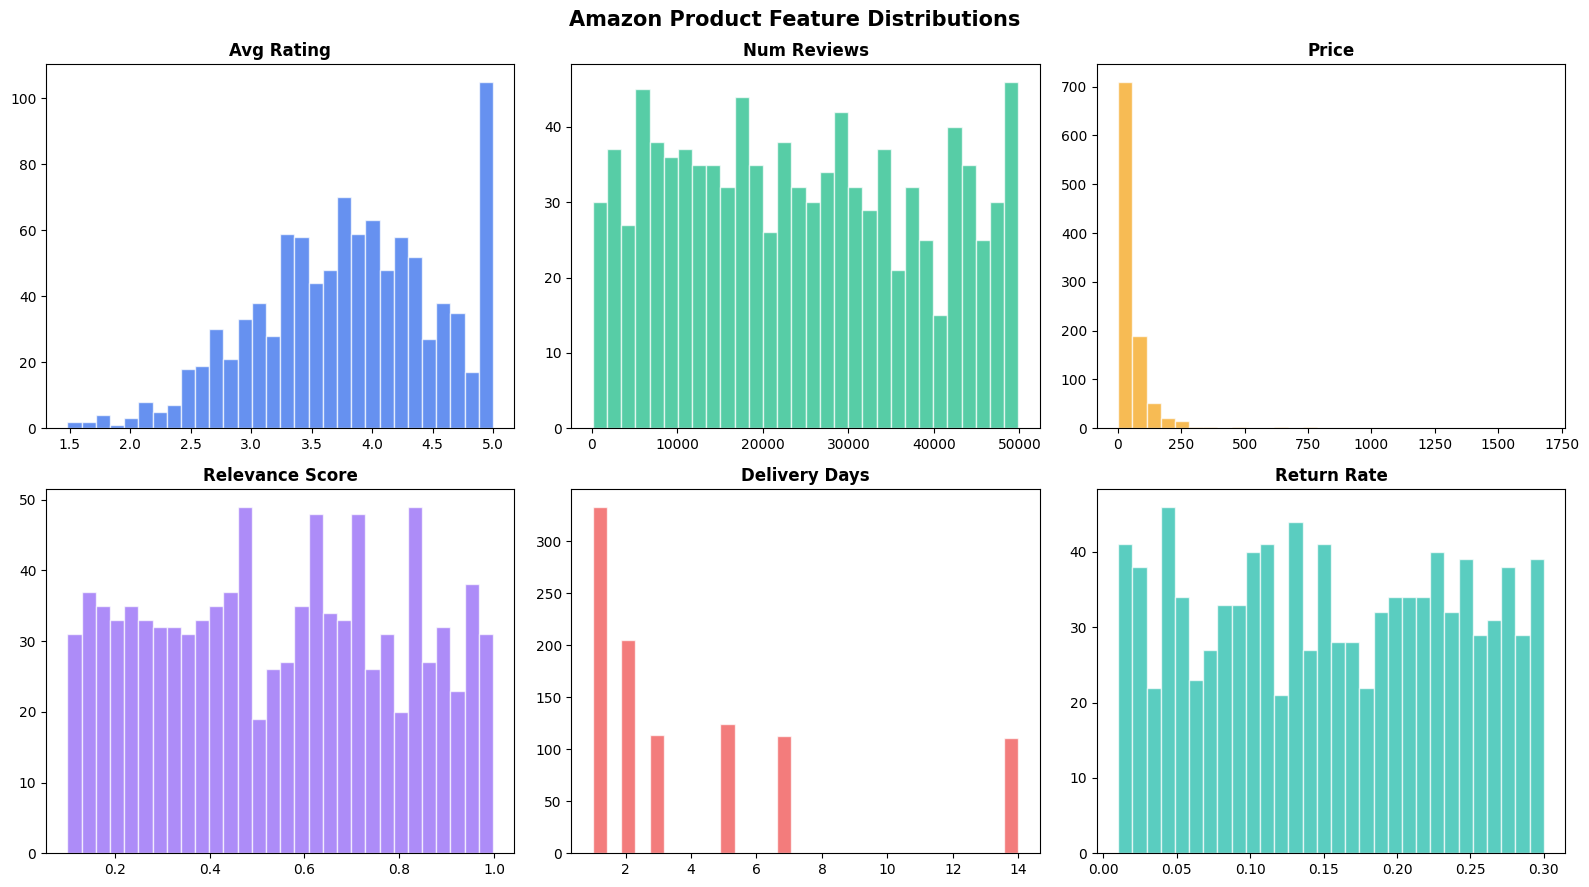

In [2]:
# EDA: Feature distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col, color in zip(axes.flat,
    ['avg_rating', 'num_reviews', 'price', 'relevance_score', 'delivery_days', 'return_rate'],
    ['#2563EB', '#10B981', '#F59E0B', '#8B5CF6', '#EF4444', '#14B8A6']):
    ax.hist(df[col], bins=30, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
plt.suptitle('Amazon Product Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 2: Build Composite Ranking Score

Amazon's A9/A10 algorithm considers multiple signals. We create:

**`rank_score = w1×relevance + w2×rating_norm + w3×review_popularity - w4×delivery_penalty - w5×return_rate + w6×prime_boost`**

In [3]:
# Normalize features
scaler = MinMaxScaler()
norm_cols = ['avg_rating', 'relevance_score', 'seller_rating', 'return_rate']
df[['rating_norm', 'relevance_norm', 'seller_norm', 'return_norm']] = scaler.fit_transform(df[norm_cols])
df['review_pop'] = scaler.fit_transform(np.log1p(df[['num_reviews']]))
df['delivery_penalty'] = scaler.fit_transform(df[['delivery_days']])
df['prime_boost'] = df['is_prime'] * 0.10

# Weights
weights = {'relevance': 0.30, 'rating': 0.20, 'reviews': 0.15,
           'delivery': 0.15, 'return': 0.10, 'prime': 0.10}

df['rank_score'] = (
    weights['relevance'] * df['relevance_norm'] +
    weights['rating'] * df['rating_norm'] +
    weights['reviews'] * df['review_pop'] -
    weights['delivery'] * df['delivery_penalty'] -
    weights['return'] * df['return_norm'] +
    df['prime_boost']
).round(5)

print("=== Top 10 Products by Rank Score ===\n")
top10 = df.nlargest(10, 'rank_score')
print(top10[['product_id', 'category', 'avg_rating', 'num_reviews', 'price',
             'delivery_days', 'is_prime', 'rank_score']].to_string(index=False))

=== Top 10 Products by Rank Score ===

product_id    category  avg_rating  num_reviews  price  delivery_days  is_prime  rank_score
ASIN_00948     Grocery        4.99        44184  19.31              2         1     0.69441
ASIN_00776      Sports        5.00        45501   6.93              1         1     0.69210
ASIN_00772      Sports        5.00        46551  19.32              1         1     0.69166
ASIN_00035        Toys        5.00        27070  42.68              1         1     0.67877
ASIN_00505      Beauty        4.46        43941   9.03              1         1     0.66779
ASIN_00506 Electronics        4.21        19589  75.92              1         1     0.66418
ASIN_00354     Grocery        4.61        36773  47.64              1         1     0.66314
ASIN_00580       Books        4.95        39869 184.82              1         1     0.64993
ASIN_00177    Clothing        4.50        13949  28.81              1         1     0.64818
ASIN_00891      Beauty        5.00       

## Step 3: Sorting Algorithm Comparison

Selection Sort     | Time: 0.0305s | Comparisons: 499,500
QuickSort          | Time: 0.0017s | Comparisons: 10,241
Python TimSort     | Time: 0.000985s | (built-in C)


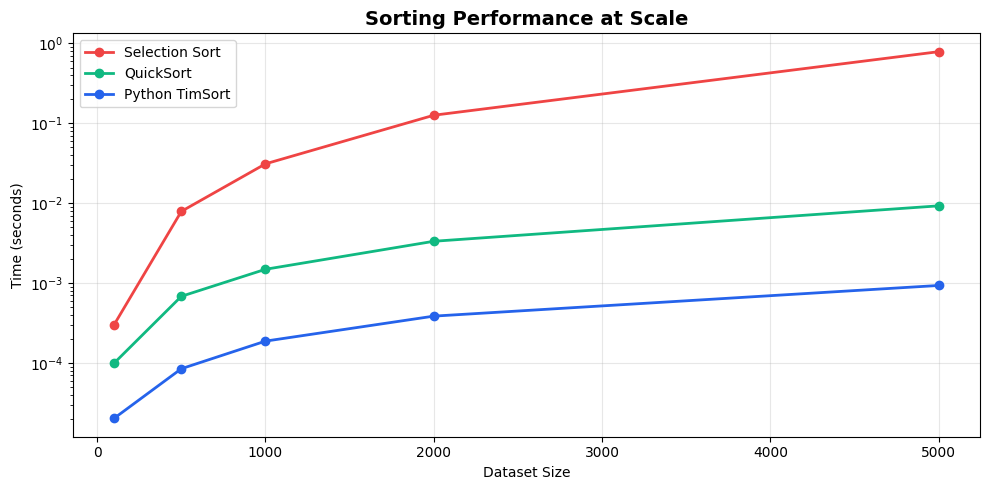

In [4]:
def selection_sort(arr, key_idx):
    data = [list(r) for r in arr]
    comps = 0
    for i in range(len(data)):
        max_i = i
        for j in range(i+1, len(data)):
            comps += 1
            if data[j][key_idx] > data[max_i][key_idx]:
                max_i = j
        data[i], data[max_i] = data[max_i], data[i]
    return data, comps

def quicksort(arr, key_idx):
    data = [list(r) for r in arr]
    comps = [0]
    def qs(lo, hi):
        if lo < hi:
            p = partition(lo, hi)
            qs(lo, p-1); qs(p+1, hi)
    def partition(lo, hi):
        pivot = data[hi][key_idx]; i = lo - 1
        for j in range(lo, hi):
            comps[0] += 1
            if data[j][key_idx] >= pivot:
                i += 1; data[i], data[j] = data[j], data[i]
        data[i+1], data[hi] = data[hi], data[i+1]
        return i + 1
    qs(0, len(data)-1)
    return data, comps[0]

# Benchmark on 1000 products
score_idx = list(df.columns).index('rank_score')
arr = df.values.tolist()

results = {}
for name, fn in [('Selection Sort', selection_sort), ('QuickSort', quicksort)]:
    t0 = time.perf_counter()
    _, comps = fn(arr, score_idx)
    elapsed = time.perf_counter() - t0
    results[name] = {'time': elapsed, 'comps': comps}
    print(f"{name:18s} | Time: {elapsed:.4f}s | Comparisons: {comps:,}")

t0 = time.perf_counter()
df_sorted = df.sort_values('rank_score', ascending=False)
ts_time = time.perf_counter() - t0
results['Python TimSort'] = {'time': ts_time, 'comps': 0}
print(f"{'Python TimSort':18s} | Time: {ts_time:.6f}s | (built-in C)")

# Scale simulation
sizes = [100, 500, 1000, 2000, 5000]
timing = {a: [] for a in ['Selection Sort', 'QuickSort', 'Python TimSort']}
for n in sizes:
    test = [(i, np.random.random()) for i in range(n)]
    for name, fn in [('Selection Sort', selection_sort), ('QuickSort', quicksort)]:
        if name == 'Selection Sort' and n > 2000:
            timing[name].append(timing[name][-1] * (n/2000)**2)
        else:
            t0 = time.perf_counter(); fn(test, 1); timing[name].append(time.perf_counter()-t0)
    t0 = time.perf_counter(); sorted(test, key=lambda x: x[1], reverse=True); timing['Python TimSort'].append(time.perf_counter()-t0)

fig, ax = plt.subplots(figsize=(10, 5))
colors = {'Selection Sort': '#EF4444', 'QuickSort': '#10B981', 'Python TimSort': '#2563EB'}
for alg, times in timing.items():
    ax.plot(sizes, times, 'o-', label=alg, color=colors[alg], linewidth=2)
ax.set_xlabel('Dataset Size'); ax.set_ylabel('Time (seconds)')
ax.set_title('Sorting Performance at Scale', fontsize=14, fontweight='bold')
ax.set_yscale('log'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Step 4: Weight Sensitivity — How Rankings Shift by Strategy

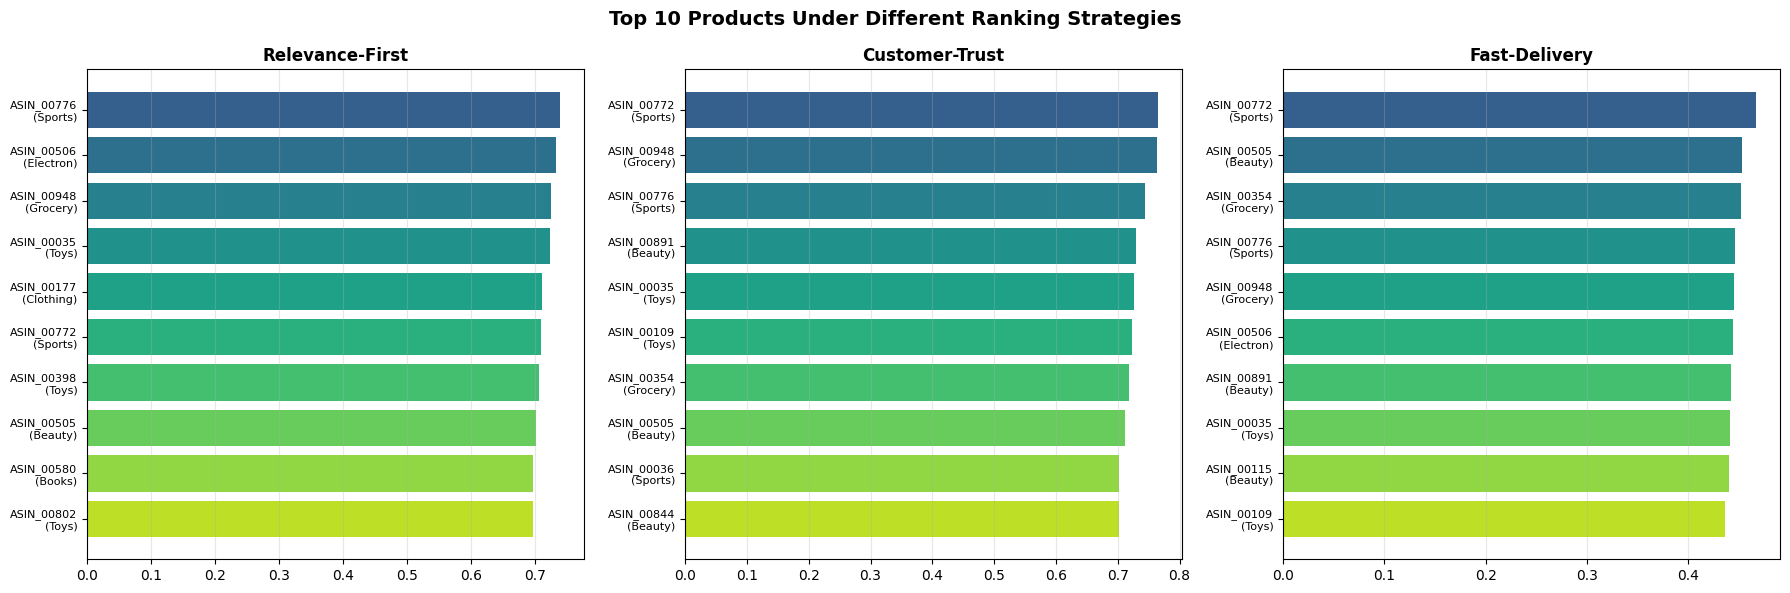

In [5]:
# Compare different ranking strategies
strategies = {
    'Relevance-First': {'relevance': 0.50, 'rating': 0.15, 'reviews': 0.10, 'delivery': 0.10, 'return': 0.10, 'prime': 0.05},
    'Customer-Trust':  {'relevance': 0.15, 'rating': 0.35, 'reviews': 0.25, 'delivery': 0.10, 'return': 0.10, 'prime': 0.05},
    'Fast-Delivery':   {'relevance': 0.15, 'rating': 0.10, 'reviews': 0.10, 'delivery': 0.40, 'return': 0.10, 'prime': 0.15},
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, (strat_name, w) in enumerate(strategies.items()):
    score = (w['relevance'] * df['relevance_norm'] + w['rating'] * df['rating_norm'] +
             w['reviews'] * df['review_pop'] - w['delivery'] * df['delivery_penalty'] -
             w['return'] * df['return_norm'] + df['is_prime'] * w['prime'])
    top = df.iloc[score.nlargest(10).index]
    ax = axes[idx]
    ax.barh(range(10), score.nlargest(10).values, color=plt.cm.viridis(np.linspace(0.3, 0.9, 10)))
    ax.set_yticks(range(10))
    ax.set_yticklabels([f"{r['product_id']}\n({r['category'][:8]})" for _, r in top.iterrows()], fontsize=8)
    ax.invert_yaxis(); ax.set_title(f'{strat_name}', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
plt.suptitle('Top 10 Products Under Different Ranking Strategies', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Step 5: Business Impact Analysis — Cost at Amazon Scale

In [6]:
# Amazon-scale cost analysis
daily_searches = 8_500_000_000
products_per_search = 1000
amazon_annual_revenue = 575_000_000_000  # $575B

print("=" * 60)
print("BUSINESS IMPACT: Algorithm Choice at Amazon Scale")
print("=" * 60)

for alg in ['Selection Sort', 'QuickSort', 'Python TimSort']:
    time_per_sort = timing[alg][2]  # 1000-item time
    total_hrs = (time_per_sort * daily_searches) / 3600
    vm_cost_hr = 0.10  # $/hr
    daily_cost = total_hrs * vm_cost_hr
    print(f"\n{alg}:")
    print(f"  Time per 1K sort: {time_per_sort:.5f}s")
    print(f"  Daily compute: {total_hrs:,.0f} VM-hours")
    print(f"  Daily cost: ${daily_cost:,.0f}")
    print(f"  Annual cost: ${daily_cost * 365:,.0f}")

# Revenue impact of latency
print(f"\n--- Latency → Revenue Impact ---")
for delay_ms in [100, 200, 500]:
    loss = amazon_annual_revenue * 0.01 * (delay_ms / 100)
    print(f"  {delay_ms}ms delay → ${loss/1e9:.1f}B/year lost")

print(f"\n💡 Key Insight: At 8.5B daily searches, even microsecond differences")
print(f"   compound to millions in compute cost and billions in revenue risk.")

BUSINESS IMPACT: Algorithm Choice at Amazon Scale

Selection Sort:
  Time per 1K sort: 0.03112s
  Daily compute: 73,477 VM-hours
  Daily cost: $7,348
  Annual cost: $2,681,904

QuickSort:
  Time per 1K sort: 0.00149s
  Daily compute: 3,513 VM-hours
  Daily cost: $351
  Annual cost: $128,211

Python TimSort:
  Time per 1K sort: 0.00019s
  Daily compute: 443 VM-hours
  Daily cost: $44
  Annual cost: $16,159

--- Latency → Revenue Impact ---
  100ms delay → $5.8B/year lost
  200ms delay → $11.5B/year lost
  500ms delay → $28.8B/year lost

💡 Key Insight: At 8.5B daily searches, even microsecond differences
   compound to millions in compute cost and billions in revenue risk.
